# Double Descent: Challenging the Classical Bias-Variance Trade-off in Linear Regression

## 1. Introduction

A central question in supervised machine learning is: *how does a model's complexity affect its ability to generalize to unseen data?* For decades, the standard answer was the **bias-variance trade-off**, a well-established theoretical framework that prescribes an optimal intermediate level of model complexity: neither too simple nor too expressive. This principle guided decades of model selection, regularization design, and the overall philosophy of avoiding overparameterization.

Recent empirical work, most notably the landmark study by **Belkin et al. (2019)** (*"Reconciling Modern Machine Learning Practice and the Bias-Variance Trade-off"*) has revealed that this picture is fundamentally incomplete. In practice, modern models such as deep neural networks and kernel machines are trained with far more parameters than training samples, yet continue to generalize well. This observation directly contradicts classical theory.

The key insight is that the test error curve is not U-shaped, but rather exhibits a **second descent**: after an initial region of classical behavior, error spikes catastrophically at the **interpolation threshold** (where the model exactly fits the training data), and then surprisingly continues to *decrease* as the model becomes even more overparameterized.

This project empirically reproduces this double descent phenomenon in the well-controlled setting of **linear regression**, using a synthetic dataset with noisy linear labels. We implement three learning methods entirely from scratch:
- **Ordinary Least Squares**
- **Ridge Regression**
- **Gradient Descent**

By systematically varying the model's dimensionality $d$ while fixing the number of training points $n$, we trace the full double descent curve, identify the interpolation threshold at $d = n$, and analyze how regularization (both explicit and implicit) tames the catastrophic failure near that threshold.


## 2. Experimental Setup

All experiments share the following structure:

| Parameter | Value              |
|---|--------------------|
| Training samples ($n_{\text{train}}$) | 100                |
| Test samples ($n_{\text{test}}$) | 1000               |
| Dimension range ($d$) | 10 to 200, step 5  |
| Noise levels ($\sigma$) | 0.2, 0.4, 0.8      |
| Random seeds | 10 seeds, averaged |
| Interpolation threshold | $d = n = 100$      |

**Why fix $n = 100$ and vary $d$?** Fixing $n$ and sweeping $d$ from underparameterized ($d < n$) to overparameterized ($d > n$) traces the full double descent curve while maintaining a controlled experimental setup where the only changing variable is model complexity.

**Why average over seeds?** The test error at any single seed is noisy — especially near the interpolation threshold where the solution is highly sensitive to the specific realization of the training data. Averaging over seeds gives a cleaner picture of the expected behavior.

**Experiment-specific configurations:**

- **Ridge Regression**: regularization $\lambda \in \{0.05, 0.1, 1\}$, results grouped by noise level.
- **Gradient Descent**: learning rates $\eta \in \{0.01, 0.1\}$, iterations $T \in \{200, 2000, 5000\}$, results grouped by noise and learning rate.
---

In [8]:
!jupytext --to py notebook.ipynb

[jupytext] Reading notebook.ipynb in format ipynb
[jupytext] Writing notebook.py (destination file replaced)


In [5]:
from functions import *
# General Parameters Setup
n_train = 100
n_test = 1000
noise_values = [0.2, 0.4, 0.8]
dim_values = np.arange(10, 201, 5) # Data Dimension
seed_values = np.arange(1,10) # fixed seeds to see the same result as me

## 3. Results and Analysis

### 3.1 Condition Number Analysis

Condition number of the training matrix $X_{\text{train}}$ as a function of model dimension $d$ (averaged over seeds). The y-axis is on a log scale. The dashed blue line marks the interpolation threshold $d = n = 100$; the dashed green line marks an acceptable condition number threshold of 30.*

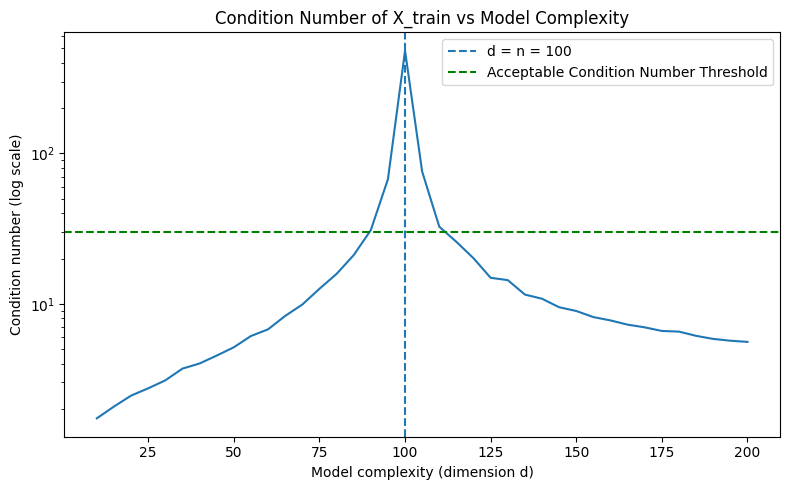

In [6]:
model = 'ls'
simulation = DDSimulation(model=model, n_train=n_train, n_test=n_test,
			 dim_values=dim_values, seed_values=seed_values, noise_values=noise_values)
simulation.plot_condition_number()

The condition number plot reveals the geometric basis of the double descent phenomenon with striking clarity.

**In the underparameterized scenario** ($d < 100$): The condition number increases gradually and monotonically as $d$ approaches $n$. This is expected — as we add more dimensions, the feature matrix becomes progressively taller relative to its width, and its columns begin to align more closely, increasing ill-conditioning. Importantly, the condition number remains well below 30 for most of this range, meaning OLS inversions are numerically stable.

**At the interpolation threshold** ($d = n = 100$): The condition number spikes dramatically to approximately $\mathbf{1000}$. This is the critical numerical singularity: $X_{\text{train}}$ is square ($100 \times 100$), and any slight numerical deficiency in its rank causes the matrix to become nearly non-invertible. This will produce an extremely unstable weight vector with enormous norm and correspondingly terrible test error.

**In the overparameterized scenario** ($d > 100$): After the spike, the condition number drops and stabilizes well below the acceptable threshold of 30, and as $d$ grows, the minimum-norm solution becomes progressively more well-behaved.

---

### 3.2 Least Squares: Observing the Double Descent Curve

Train MSE (blue) and Test MSE (orange) for Ordinary Least Squares across dimensions $d \in [10, 200]$ for three noise levels: $\sigma = 0.2$ (left), $\sigma = 0.4$ (center), $\sigma = 0.8$ (right). The dashed vertical line marks the interpolation threshold at $d = 100$.

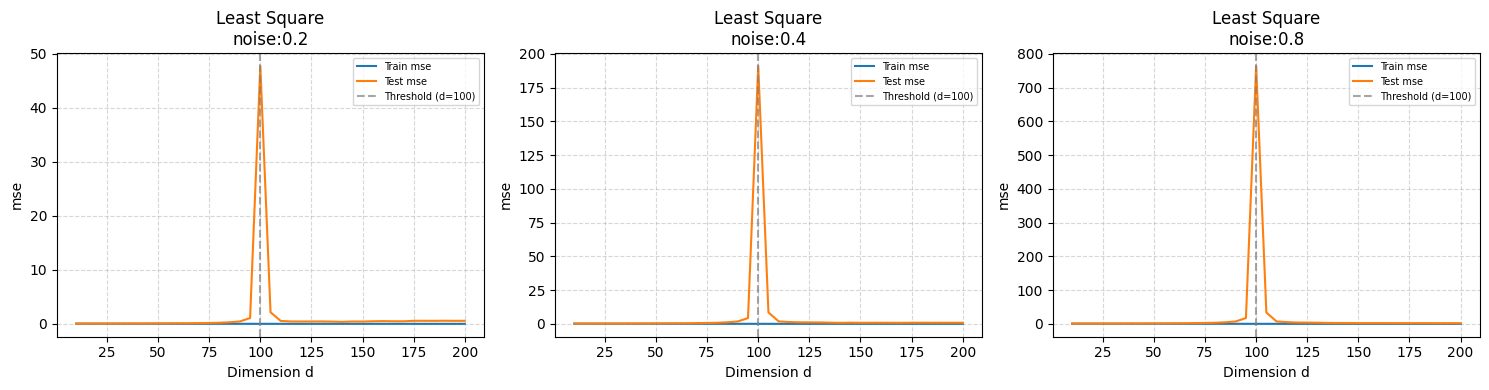

In [7]:
simulation.run_simulation()
simulation.plot_simulation(train=True)

This figure reproducing the classical double descent curve in its full form.

**Train error (blue)**: The training MSE behaves as expected from theory.
- For $d < n$: Training error is non-zero — the model has fewer degrees of freedom than data points, so it cannot interpolate and some residual error remains.
- For $d \geq n$: Training error drops to effectively zero for all noise levels. This is the definition of interpolation: the model fits every training point perfectly, regardless of noise. Crucially, this means the model is memorizing the noise in the training labels.

**Test error (orange)**: This is where the double descent phenomenon lives:

1. **Classical descent** ($d \ll n$, roughly $d < 70$): Test error starts moderate and slowly decreases as the model gains more capacity to learn the true signal. This is the classical "bias reduction" part of the U-shape.
2. **Pre-threshold increase** ($70 < d < 100$): As $d$ approaches $n$, test error begins to rise — the model is gaining complexity faster than it can be controlled by the data. This is the classical "variance increase" that forms the right arm of the U.
3. **Catastrophic spike at $d = n$**: Test error explodes at the interpolation threshold. The magnitude scales dramatically with noise. Higher noise means this alignment amplifies into a proportionally larger error on the test set.
4. **Second descent** ($d > n$): After the spike, test error falls dramatically. As $d$ grows beyond 100, the minimum-norm interpolant becomes progressively better-regularized and test error decreases.

---

### 3.3 Ridge Regression: Regularization as a Remedy

Test MSE for Ridge Regression with three regularization strengths ($\lambda \in \{0.05, 0.1, 1\}$) across dimensions $d \in [10, 200]$, for noise levels $\sigma = 0.2$ (left), $\sigma = 0.4$ (center), $\sigma = 0.8$ (right).

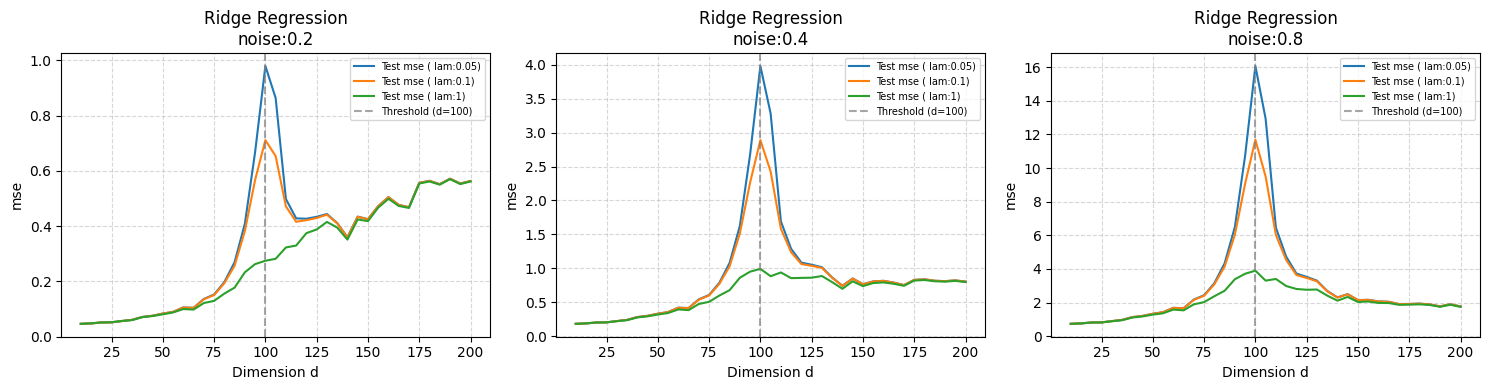

In [4]:
model = 'ridge'
model_kwargs_values = {'lam':[0.05,0.1,1]}
simulation = DDSimulation(model=model, n_train=n_train, n_test=n_test,
			 dim_values=dim_values, seed_values=seed_values, noise_values=noise_values, model_kwargs_values=model_kwargs_values)
simulation.run_simulation()
simulation.plot_simulation(group_attrs=['noise'])

Ridge regression provides a direct illustration of how explicit regularization controls the double descent phenomenon.

**Dramatic reduction of the interpolation peak**: Comparing Figure 3 to Figure 2, the peak at $d = n = 100$ is reduced by a large factor across all noise levels.

**Effect of $\lambda$ on the curve shape**:

- **Weak regularization** ($\lambda = 0.05$, blue): The curve closely resembles OLS but with a reduced peak. The double descent shape is still visible.
- **Moderate regularization** ($\lambda = 0.1$, orange): Peak is further reduced. Good balance between bias and variance reduction across noise levels.
- **Strong regularization** ($\lambda = 1$, green): The interpolation peak is almost entirely eliminated.

---

### 3.4 Gradient Descent: Implicit Regularization via Early Stopping

Test MSE for Gradient Descent with learning rates $\eta \in \{0.01, 0.1\}$ and iteration counts $T \in \{200, 2000, 5000\}$. Results are shown for two (noise, learning rate) combinations. The dashed vertical line marks the interpolation threshold at $d = 100$.

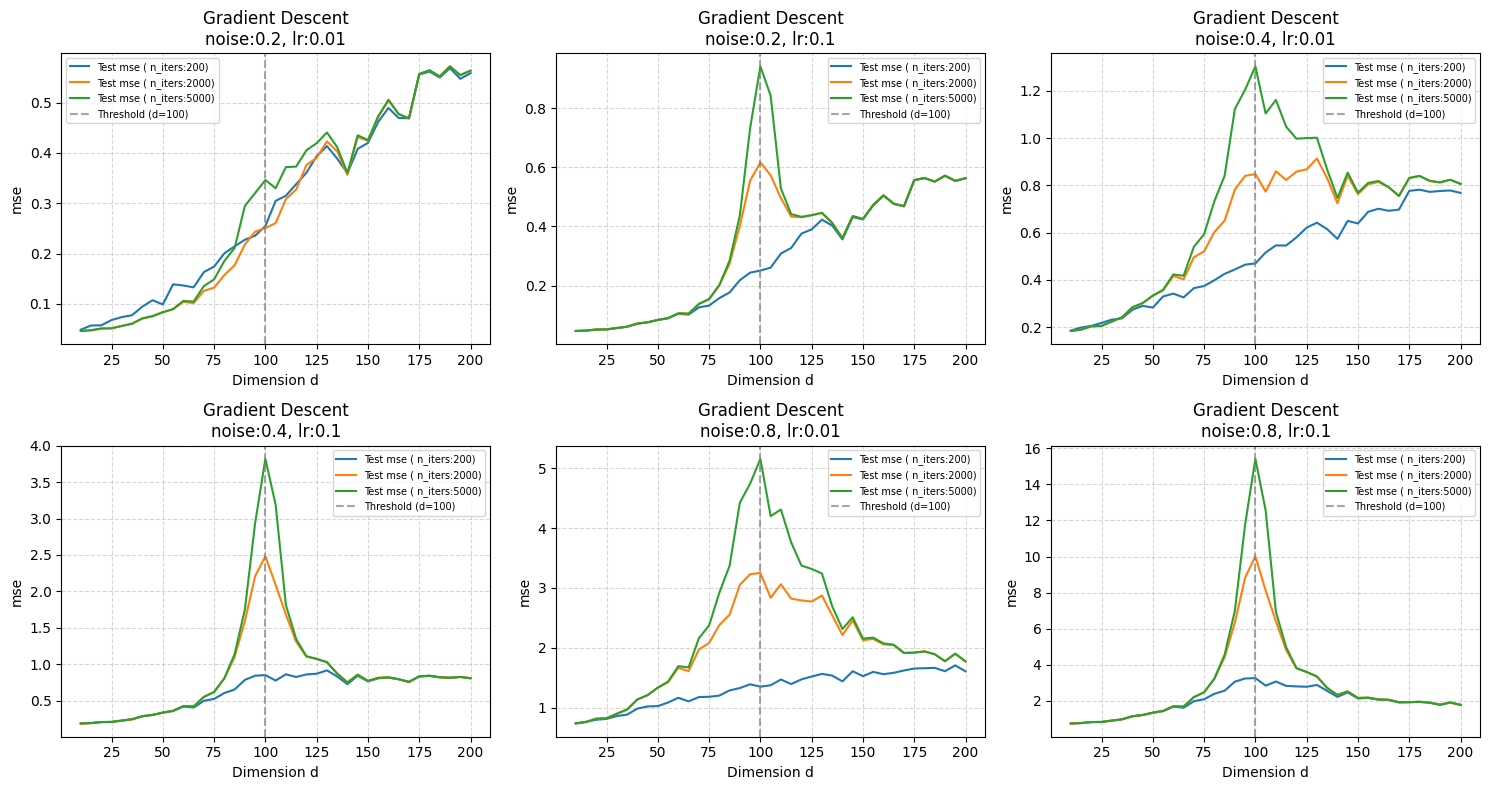

In [5]:
model = 'gd'
model_kwargs_values = {'n_iters':[200,2000,5000],'lr':[0.01,0.1]}
seed_values = np.arange(1,10)
simulation = DDSimulation(model=model, n_train=n_train, n_test=n_test,
			 dim_values=dim_values, seed_values=seed_values, noise_values=noise_values, model_kwargs_values=model_kwargs_values)
simulation.run_simulation()
simulation.plot_simulation(group_attrs=['noise','lr'])

The gradient descent experiment reveals one of the most elegant phenomena in modern machine learning: **implicit regularization through early stopping**.

**Fewer iterations = stronger implicit regularization**: Across both learning rate settings, the pattern is consistent — models trained with fewer iterations (blue, $T=200$) have lower test MSE than those trained for more iterations (green, $T=5000$), especially near and beyond the interpolation threshold.

**Effect of learning rate**: Comparing the two panels:
- With $\eta = 0.01$: Even 5000 iterations are not enough for full convergence, so all three curves show significant implicit regularization. The spread between $T=200$ and $T=5000$ is smaller, because GD moves more slowly and is farther from convergence.
- With $\eta = 0.1$: Convergence is faster. With 5000 iterations and $\eta = 0.1$, the solution is closer to the true OLS/min-norm solution — the peak at $d = 100$ is sharper and more prominent. This confirms that the $T=5000$, $\eta=0.1$ combination is the "closest to converged" among those tested, approximating the behavior of OLS.

**Double descent in GD**: For the higher-iteration, higher-learning-rate setting ($T=5000$, $\eta=0.1$, green), the characteristic double descent peak at $d = 100$ is clearly visible and most pronounced. This confirms that, given sufficient iterations, GD recovers the same OLS solution and thus the same double descent behavior.

---